In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Module 4\\Assignment 3\\Auto-1.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,name
0,18.0,8,307.0,130,3504,12.0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,ford torino


Text(0.5, 1.0, 'Time to accelerate from 0 to 60 mph (sec.)')

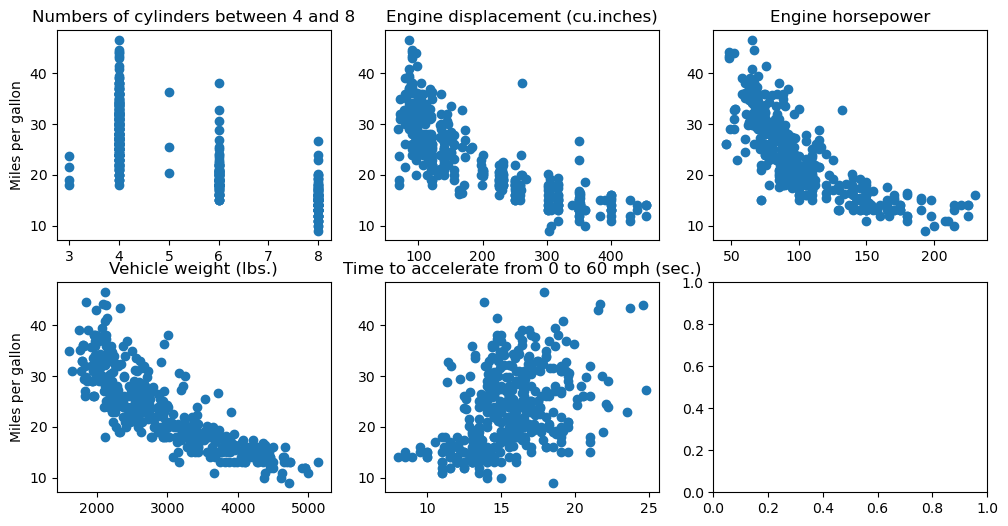

In [3]:
figure, axis = plt.subplots(2,3, figsize = (12,6))
axis[0,0].scatter(data.cylinders, data.mpg)
axis[0,0].set_title("Numbers of cylinders between 4 and 8")
axis[0,0].set_ylabel("Miles per gallon")
axis[0,1].scatter(data.displacement, data.mpg)
axis[0,1].set_title("Engine displacement (cu.inches)")
axis[0,2].scatter(data.horsepower, data.mpg)
axis[0,2].set_title("Engine horsepower")
axis[1,0].scatter(data.weight, data.mpg)
axis[1,0].set_title("Vehicle weight (lbs.)")
axis[1,0].set_ylabel("Miles per gallon")
axis[1,1].scatter(data.acceleration, data.mpg)
axis[1,1].set_title("Time to accelerate from 0 to 60 mph (sec.)")

In [4]:
#Model 1

In [5]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
displacement = poly.fit_transform(data.iloc[:,2:3])
displacement = pd.DataFrame(displacement[:,1:], columns = ["displacement1", "displacement2"])
horsepower = poly.fit_transform(data.iloc[:,3:4])
horsepower = pd.DataFrame(horsepower[:,1:], columns = ["horsepower1", "horsepower2"])
weight = poly.fit_transform(data.iloc[:,4:5])
weight = pd.DataFrame(weight[:,1:], columns = ["weight1", "weight2"])
data = pd.concat([data.iloc[:,0:2],displacement, horsepower, weight, data.iloc[:,5:6]], axis = 1)
data

,mpg,cylinders,displacement1,displacement2,horsepower1,horsepower2,weight1,weight2,acceleration
0,18.0,8,307.0,94249.0,130.0,16900.0,3504.0,12278016.0,12.0
1,15.0,8,350.0,122500.0,165.0,27225.0,3693.0,13638249.0,11.5
2,18.0,8,318.0,101124.0,150.0,22500.0,3436.0,11806096.0,11.0
3,16.0,8,304.0,92416.0,150.0,22500.0,3433.0,11785489.0,12.0
4,17.0,8,302.0,91204.0,140.0,19600.0,3449.0,11895601.0,10.5
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,19600.0,86.0,7396.0,2790.0,7784100.0,15.6
388,44.0,4,97.0,9409.0,52.0,2704.0,2130.0,4536900.0,24.6
389,32.0,4,135.0,18225.0,84.0,7056.0,2295.0,5267025.0,11.6
390,28.0,4,120.0,14400.0,79.0,6241.0,2625.0,6890625.0,18.6


In [6]:
import statsmodels.api as sm
ols = sm.OLS(data.iloc[:,0], sm.add_constant(data.iloc[:,1:9]))
lm = ols.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     151.8
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          9.04e-114
Time:                        22:52:56   Log-Likelihood:                -1081.3
No. Observations:                 392   AIC:                             2181.
Df Residuals:                     383   BIC:                             2216.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            62.5637      4.455     14.042

Text(0, 0.5, 'Residuals')

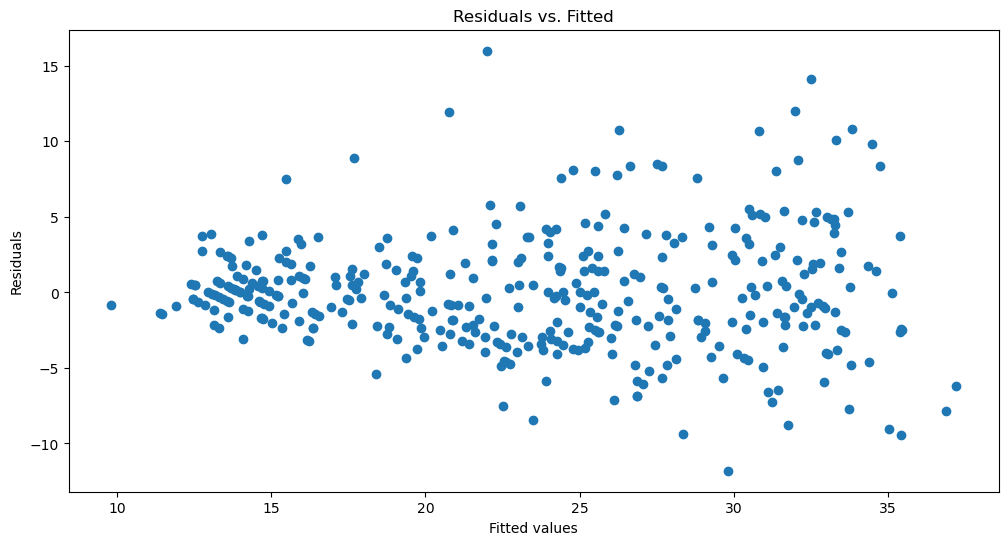

In [7]:
fitted_y = lm.fittedvalues
residual = lm.resid
plt.figure(figsize = (12,6))
plt.scatter(fitted_y,residual)
plt.title("Residuals vs. Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

Text(0, 0.5, 'Frequency')

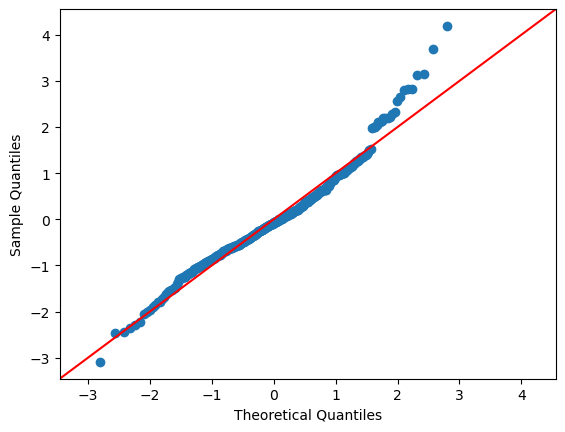

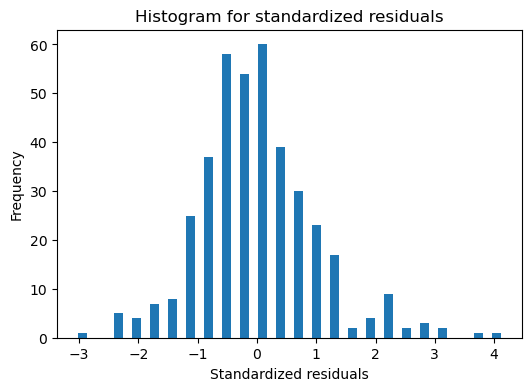

In [8]:
from sklearn.preprocessing import scale
residual_norm = scale(residual)
sm.qqplot(residual_norm, line='45')
plt.figure(figsize = (6,4))
plt.title("Histogram for standardized residuals")
plt.hist(x=residual_norm, bins='auto', rwidth=0.5)
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [9]:
#Model 2

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Module 4\\Assignment 3\\Auto-1.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,name
0,18.0,8,307.0,130,3504,12.0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,ford torino


In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
displacement = np.log(data.iloc[:,2:3])
displacement = displacement.rename(columns={"displacement":"log_displacement"})
horsepower = np.log(data.iloc[:,3:4])
horsepower = horsepower.rename(columns={"horsepower":"log_horsepower"})
weight = np.log(data.iloc[:,4:5])
weight = weight.rename(columns={"weight":"log_weight"})
data = pd.concat([data.iloc[:,0:2], displacement, horsepower, weight, data.iloc[:,5:6]], axis = 1)
data

,mpg,cylinders,log_displacement,log_horsepower,log_weight,acceleration
0,18.0,8,5.726848,4.867534,8.161660,12.0
1,15.0,8,5.857933,5.105945,8.214194,11.5
2,18.0,8,5.762051,5.010635,8.142063,11.0
3,16.0,8,5.717028,5.010635,8.141190,12.0
4,17.0,8,5.710427,4.941642,8.145840,10.5
...,...,...,...,...,...,...
387,27.0,4,4.941642,4.454347,7.933797,15.6
388,44.0,4,4.574711,3.951244,7.663877,24.6
389,32.0,4,4.905275,4.430817,7.738488,11.6
390,28.0,4,4.787492,4.369448,7.872836,18.6


Text(0.5, 1.0, 'Time to accelerate from 0 to 60 mph (sec.)')

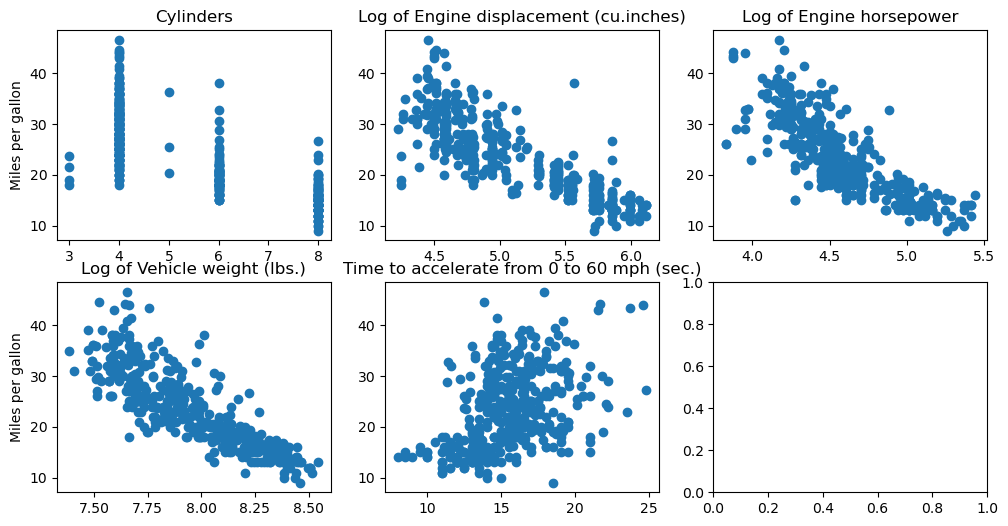

In [13]:
figure, axis = plt.subplots(2,3, figsize=(12,6))
axis[0,0].scatter(data.cylinders, data.mpg)
axis[0,0].set_title("Cylinders")
axis[0,0].set_ylabel("Miles per gallon")
axis[0,1].scatter(data.log_displacement, data.mpg)
axis[0,1].set_title("Log of Engine displacement (cu.inches)")
axis[0,2].scatter(data.log_horsepower, data.mpg)
axis[0,2].set_title("Log of Engine horsepower")
axis[1,0].scatter(data.log_weight, data.mpg)
axis[1,0].set_title("Log of Vehicle weight (lbs.)")
axis[1,0].set_ylabel("Miles per gallon")
axis[1,1].scatter(data.acceleration, data.mpg)
axis[1,1].set_title("Time to accelerate from 0 to 60 mph (sec.)")


In [14]:
import statsmodels.api as sm
ols = sm.OLS(data.iloc[:,0], sm.add_constant(data.iloc[:,1:6]))
lm = ols.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     229.3
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          3.55e-113
Time:                        22:52:58   Log-Likelihood:                -1090.9
No. Observations:                 392   AIC:                             2194.
Df Residuals:                     386   BIC:                             2218.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              157.1480     12.362  

Text(0, 0.5, 'Residuals')

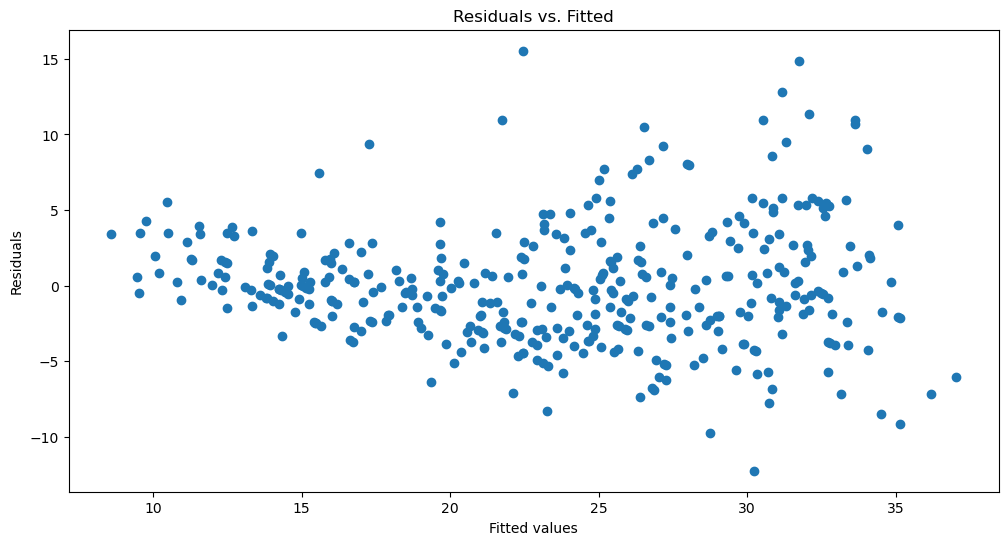

In [15]:
fitted_y = lm.fittedvalues
residual = lm.resid
plt.figure(figsize = (12,6))
plt.scatter(fitted_y,residual)
plt.title("Residuals vs. Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

Text(0, 0.5, 'Frequency')

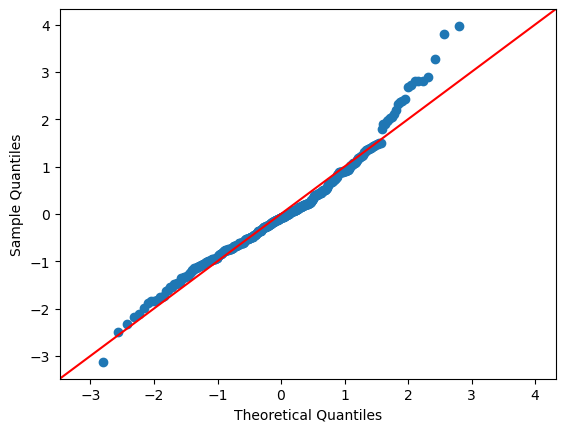

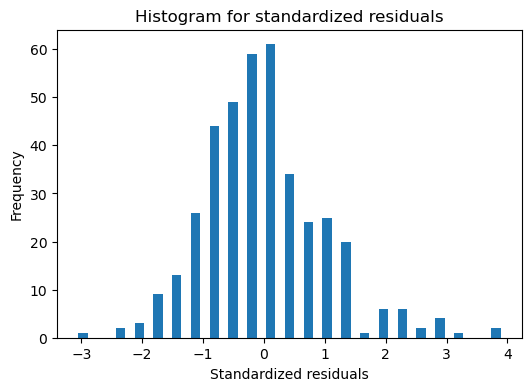

In [16]:
from sklearn.preprocessing import scale
residual_norm = scale(residual)
sm.qqplot(residual_norm, line='45')
plt.figure(figsize = (6,4))
plt.title("Histogram for standardized residuals")
plt.hist(x=residual_norm, bins='auto', rwidth=0.5)
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [17]:
#Model 3

In [18]:
data = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Module 4\\Assignment 3\\Auto-1.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,name
0,18.0,8,307.0,130,3504,12.0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,ford torino


In [19]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
mpg = np.log(data.iloc[:,0:1])
mpg = mpg.rename(columns={"mpg":"log_mpg"})
data = pd.concat([mpg, data.iloc[:,1:6]], axis = 1)
data

,log_mpg,cylinders,displacement,horsepower,weight,acceleration
0,2.890372,8,307.0,130,3504,12.0
1,2.708050,8,350.0,165,3693,11.5
2,2.890372,8,318.0,150,3436,11.0
3,2.772589,8,304.0,150,3433,12.0
4,2.833213,8,302.0,140,3449,10.5
...,...,...,...,...,...,...
387,3.295837,4,140.0,86,2790,15.6
388,3.784190,4,97.0,52,2130,24.6
389,3.465736,4,135.0,84,2295,11.6
390,3.332205,4,120.0,79,2625,18.6


In [20]:
import statsmodels.api as sm
ols = sm.OLS(data.iloc[:,0], sm.add_constant(data.iloc[:,1:6]))
lm = ols.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     292.9
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          6.18e-129
Time:                        22:52:59   Log-Likelihood:                 174.31
No. Observations:                 392   AIC:                            -336.6
Df Residuals:                     386   BIC:                            -312.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.2203      0.098     42.956   

Text(0, 0.5, 'Residuals')

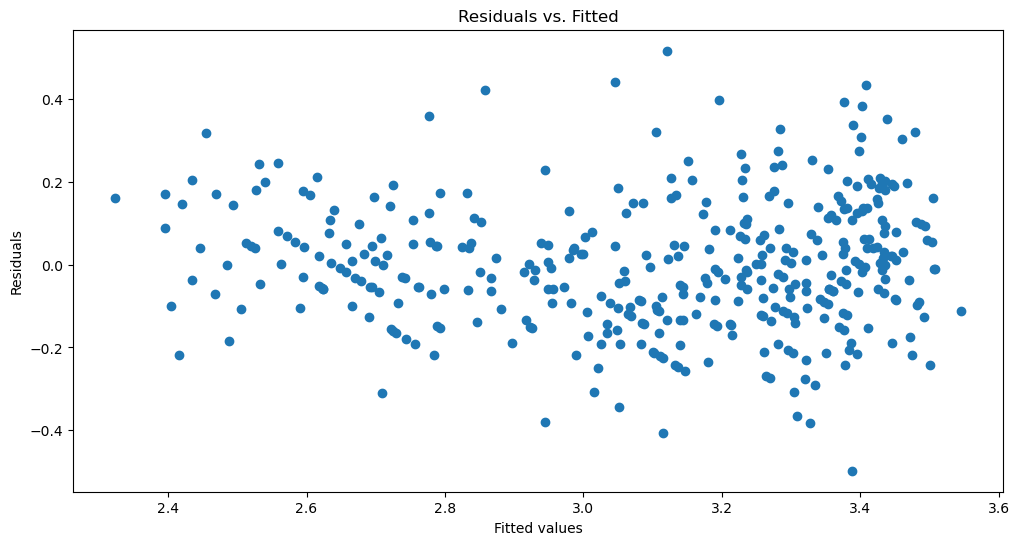

In [21]:
fitted_y = lm.fittedvalues
residual = lm.resid
plt.figure(figsize = (12,6))
plt.scatter(fitted_y,residual)
plt.title("Residuals vs. Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

Text(0, 0.5, 'Frequency')

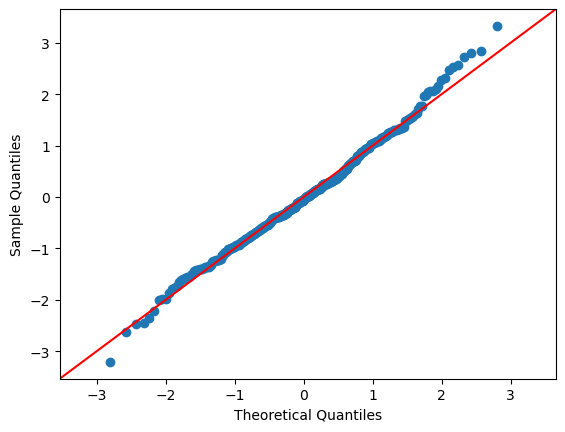

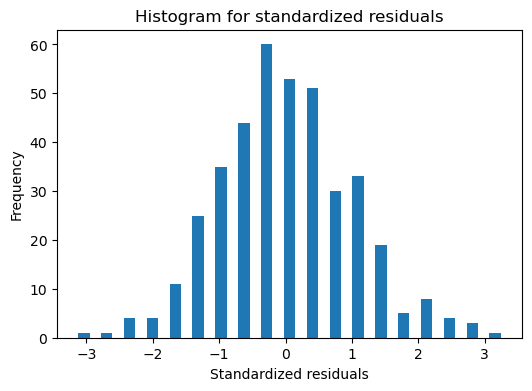

In [22]:
from sklearn.preprocessing import scale
residual_norm = scale(residual)
sm.qqplot(residual_norm, line='45')
plt.figure(figsize = (6,4))
plt.title("Histogram for standardized residuals")
plt.hist(x=residual_norm, bins='auto', rwidth=0.5)
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [23]:
#model 4

In [24]:
data = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Module 4\\Assignment 3\\Auto-1.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,name
0,18.0,8,307.0,130,3504,12.0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,ford torino


In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
mpg = np.log(data.iloc[:,0:1])
mpg = mpg.rename(columns={"mpg":"log_mpg"})
displacement = np.log(data.iloc[:,2:3])
displacement = displacement.rename(columns={"displacement":"log_displacement"})
horsepower = np.log(data.iloc[:,3:4])
horsepower = horsepower.rename(columns={"horsepower":"log_horsepower"})
weight = np.log(data.iloc[:,4:5])
weight = weight.rename(columns={"weight":"log_weight"})
data = pd.concat([mpg,data.iloc[:,1:2],displacement, horsepower, weight, data.iloc[:,5:6]], axis = 1)
data

,log_mpg,cylinders,log_displacement,log_horsepower,log_weight,acceleration
0,2.890372,8,5.726848,4.867534,8.161660,12.0
1,2.708050,8,5.857933,5.105945,8.214194,11.5
2,2.890372,8,5.762051,5.010635,8.142063,11.0
3,2.772589,8,5.717028,5.010635,8.141190,12.0
4,2.833213,8,5.710427,4.941642,8.145840,10.5
...,...,...,...,...,...,...
387,3.295837,4,4.941642,4.454347,7.933797,15.6
388,3.784190,4,4.574711,3.951244,7.663877,24.6
389,3.465736,4,4.905275,4.430817,7.738488,11.6
390,3.332205,4,4.787492,4.369448,7.872836,18.6


In [26]:
import statsmodels.api as sm
ols = sm.OLS(data.iloc[:,0], sm.add_constant(data.iloc[:,1:6]))
lm = ols.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     319.0
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          1.20e-134
Time:                        22:52:59   Log-Likelihood:                 187.69
No. Observations:                 392   AIC:                            -363.4
Df Residuals:                     386   BIC:                            -339.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.7657      0.474  

Text(0, 0.5, 'Residuals')

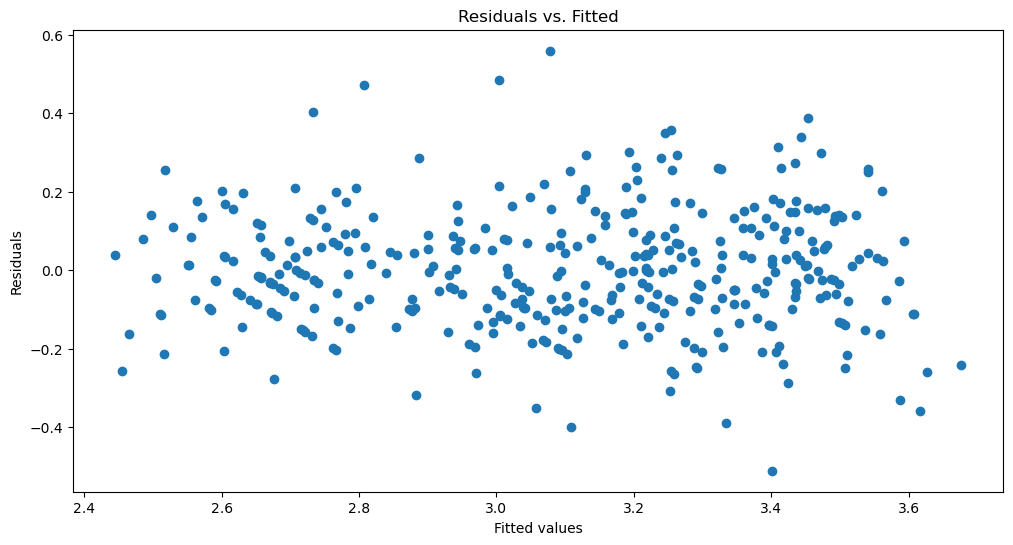

In [27]:
fitted_y = lm.fittedvalues
residual = lm.resid
plt.figure(figsize = (12,6))
plt.scatter(fitted_y,residual)
plt.title("Residuals vs. Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

Text(0, 0.5, 'Frequency')

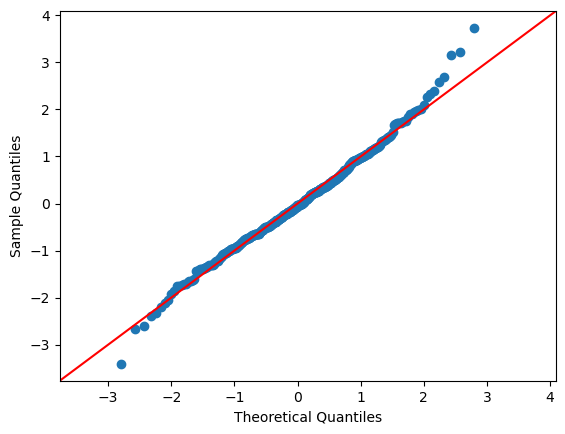

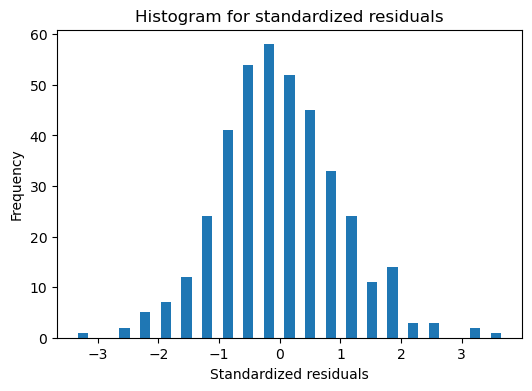

In [28]:
from sklearn.preprocessing import scale
residual_norm = scale(residual)
sm.qqplot(residual_norm, line='45')
plt.figure(figsize = (6,4))
plt.title("Histogram for standardized residuals")
plt.hist(x=residual_norm, bins='auto', rwidth=0.5)
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")

In [29]:
#model 5

In [30]:
data = pd.read_csv("d:\\UAH GO CHARGERS\\Spring 26\\MSC450\\Module 4\\Assignment 3\\Auto-1.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,name
0,18.0,8,307.0,130,3504,12.0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,ford torino


In [31]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
displacement = np.log(data.iloc[:,2:3])
displacement = displacement.rename(columns={"displacement":"log_displacement"})
horsepower = np.log(data.iloc[:,3:4])
horsepower = horsepower.rename(columns={"horsepower":"log_horsepower"})
weight = np.log(data.iloc[:,4:5])
weight = weight.rename(columns={"weight":"log_weight"})
data = pd.concat([data.iloc[:,0:2],displacement, horsepower, weight, data.iloc[:,5:6]], axis = 1)
data

,mpg,cylinders,log_displacement,log_horsepower,log_weight,acceleration
0,18.0,8,5.726848,4.867534,8.161660,12.0
1,15.0,8,5.857933,5.105945,8.214194,11.5
2,18.0,8,5.762051,5.010635,8.142063,11.0
3,16.0,8,5.717028,5.010635,8.141190,12.0
4,17.0,8,5.710427,4.941642,8.145840,10.5
...,...,...,...,...,...,...
387,27.0,4,4.941642,4.454347,7.933797,15.6
388,44.0,4,4.574711,3.951244,7.663877,24.6
389,32.0,4,4.905275,4.430817,7.738488,11.6
390,28.0,4,4.787492,4.369448,7.872836,18.6


In [32]:
import scipy.stats as stats
Z, fit_lambda = stats.boxcox(data.mpg)
print(fit_lambda)

0.19123084478293514


In [33]:
import statsmodels.api as sm
ols = sm.OLS(Z, sm.add_constant(data.iloc[:,1:6]))
lm = ols.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     305.0
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          1.26e-131
Time:                        22:53:00   Log-Likelihood:                -50.812
No. Observations:                 392   AIC:                             113.6
Df Residuals:                     386   BIC:                             137.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.5514      0.870  

Text(0, 0.5, 'Residuals')

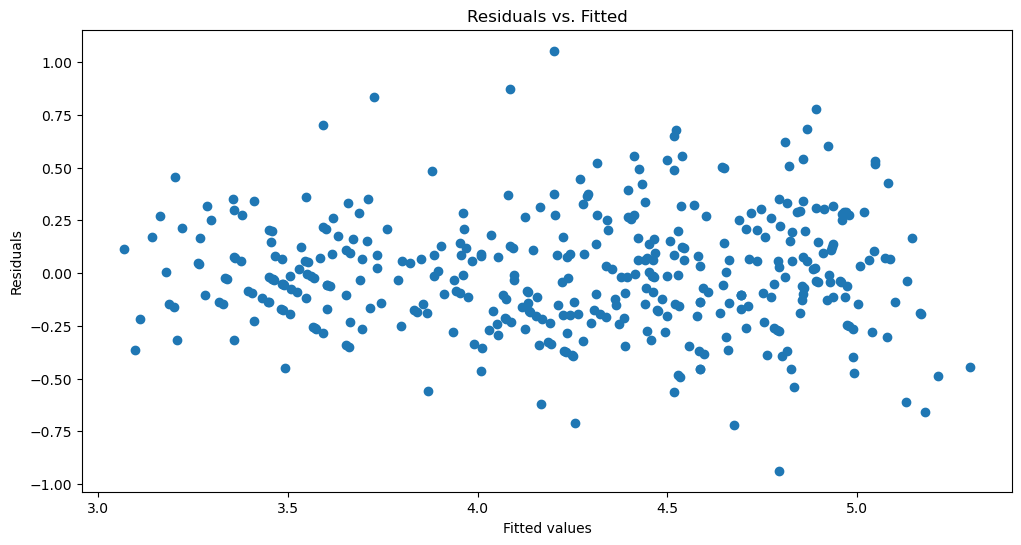

In [34]:
fitted_y = lm.fittedvalues
residual = lm.resid
plt.figure(figsize = (12,6))
plt.scatter(fitted_y,residual)
plt.title("Residuals vs. Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

Text(0, 0.5, 'Frequency')

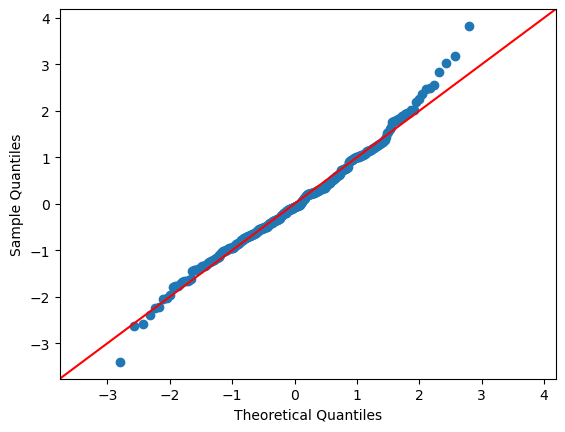

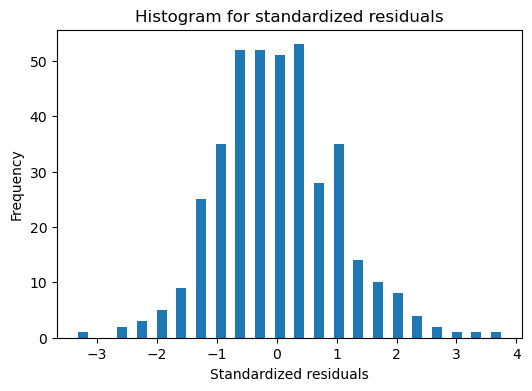

In [35]:
from sklearn.preprocessing import scale
residual_norm = scale(residual)
sm.qqplot(residual_norm, line='45')
plt.figure(figsize = (6,4))
plt.title("Histogram for standardized residuals")
plt.hist(x=residual_norm, bins='auto', rwidth=0.5)
plt.xlabel("Standardized residuals")
plt.ylabel("Frequency")